# Recommendation Algorithm Benchmark — MovieLens 100K

**Goal:** Compare 8 recommendation algorithms under a single, fair evaluation
protocol to understand what actually drives recommendation quality.

**Audience:** This notebook is self-contained. No prior knowledge of the codebase
is assumed. All figures and tables are generated from the final held-out test set.

---
| | |
|---|---|
| Dataset | MovieLens 100K |
| Models evaluated | 8 (non-personalised → neural) |
| Primary metric | NDCG@10 |
| Evaluation | Time-based train / val / test split |
| Final training | Train + val combined (tuned params for Week 3; defaults for Week 1–2) |


## Setup

In [1]:
import sys, json, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from IPython.display import Image as IPImage, display
from pathlib import Path

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

def show_png(path, width=1100):
    """Display a saved PNG inline using IPython — no matplotlib overhead."""
    display(IPImage(path, width=width))


## 1. Dataset — MovieLens 100K

[MovieLens 100K](https://grouplens.org/datasets/movielens/100k/) is a classic
collaborative filtering benchmark collected by GroupLens Research. It contains
explicit star ratings (1–5) from real users on movies.

Before modelling, a minimum-activity filter is applied:
users and items with fewer than **5 ratings** are removed. This prevents
models from being evaluated on users for whom almost no signal exists, and
removes items so rare that collaborative patterns cannot form.


In [2]:
from src.data_prep.loader import load_and_split
data = load_and_split()

train_val = pd.concat([data["train"], data["val"]], ignore_index=True)
r = data["ratings"]

stats = pd.DataFrame({
    "Metric": [
        "Users (after filter)", "Items (after filter)", "Ratings (after filter)",
        "Matrix density", "Avg ratings per user", "Avg ratings per item",
        "Rating mean", "Rating std dev",
        "Train rows", "Val rows", "Test rows",
    ],
    "Value": [
        f"{r.user_id.nunique():,}",
        f"{r.item_id.nunique():,}",
        f"{len(r):,}",
        f"{len(r) / (r.user_id.nunique() * r.item_id.nunique()):.2%}",
        f"{r.groupby('user_id').size().mean():.1f}",
        f"{r.groupby('item_id').size().mean():.1f}",
        f"{r.rating.mean():.2f}",
        f"{r.rating.std():.2f}",
        f"{len(data['train']):,}",
        f"{len(data['val']):,}",
        f"{len(data['test']):,}",
    ]
})
display(stats.set_index("Metric"))


,Value
Metric,
Users (after filter),943
Items (after filter),"1,349"
Ratings (after filter),"99,287"
Matrix density,7.80%
Avg ratings per user,105.3
Avg ratings per item,73.6
Rating mean,3.54
Rating std dev,1.12
Train rows,"80,225"


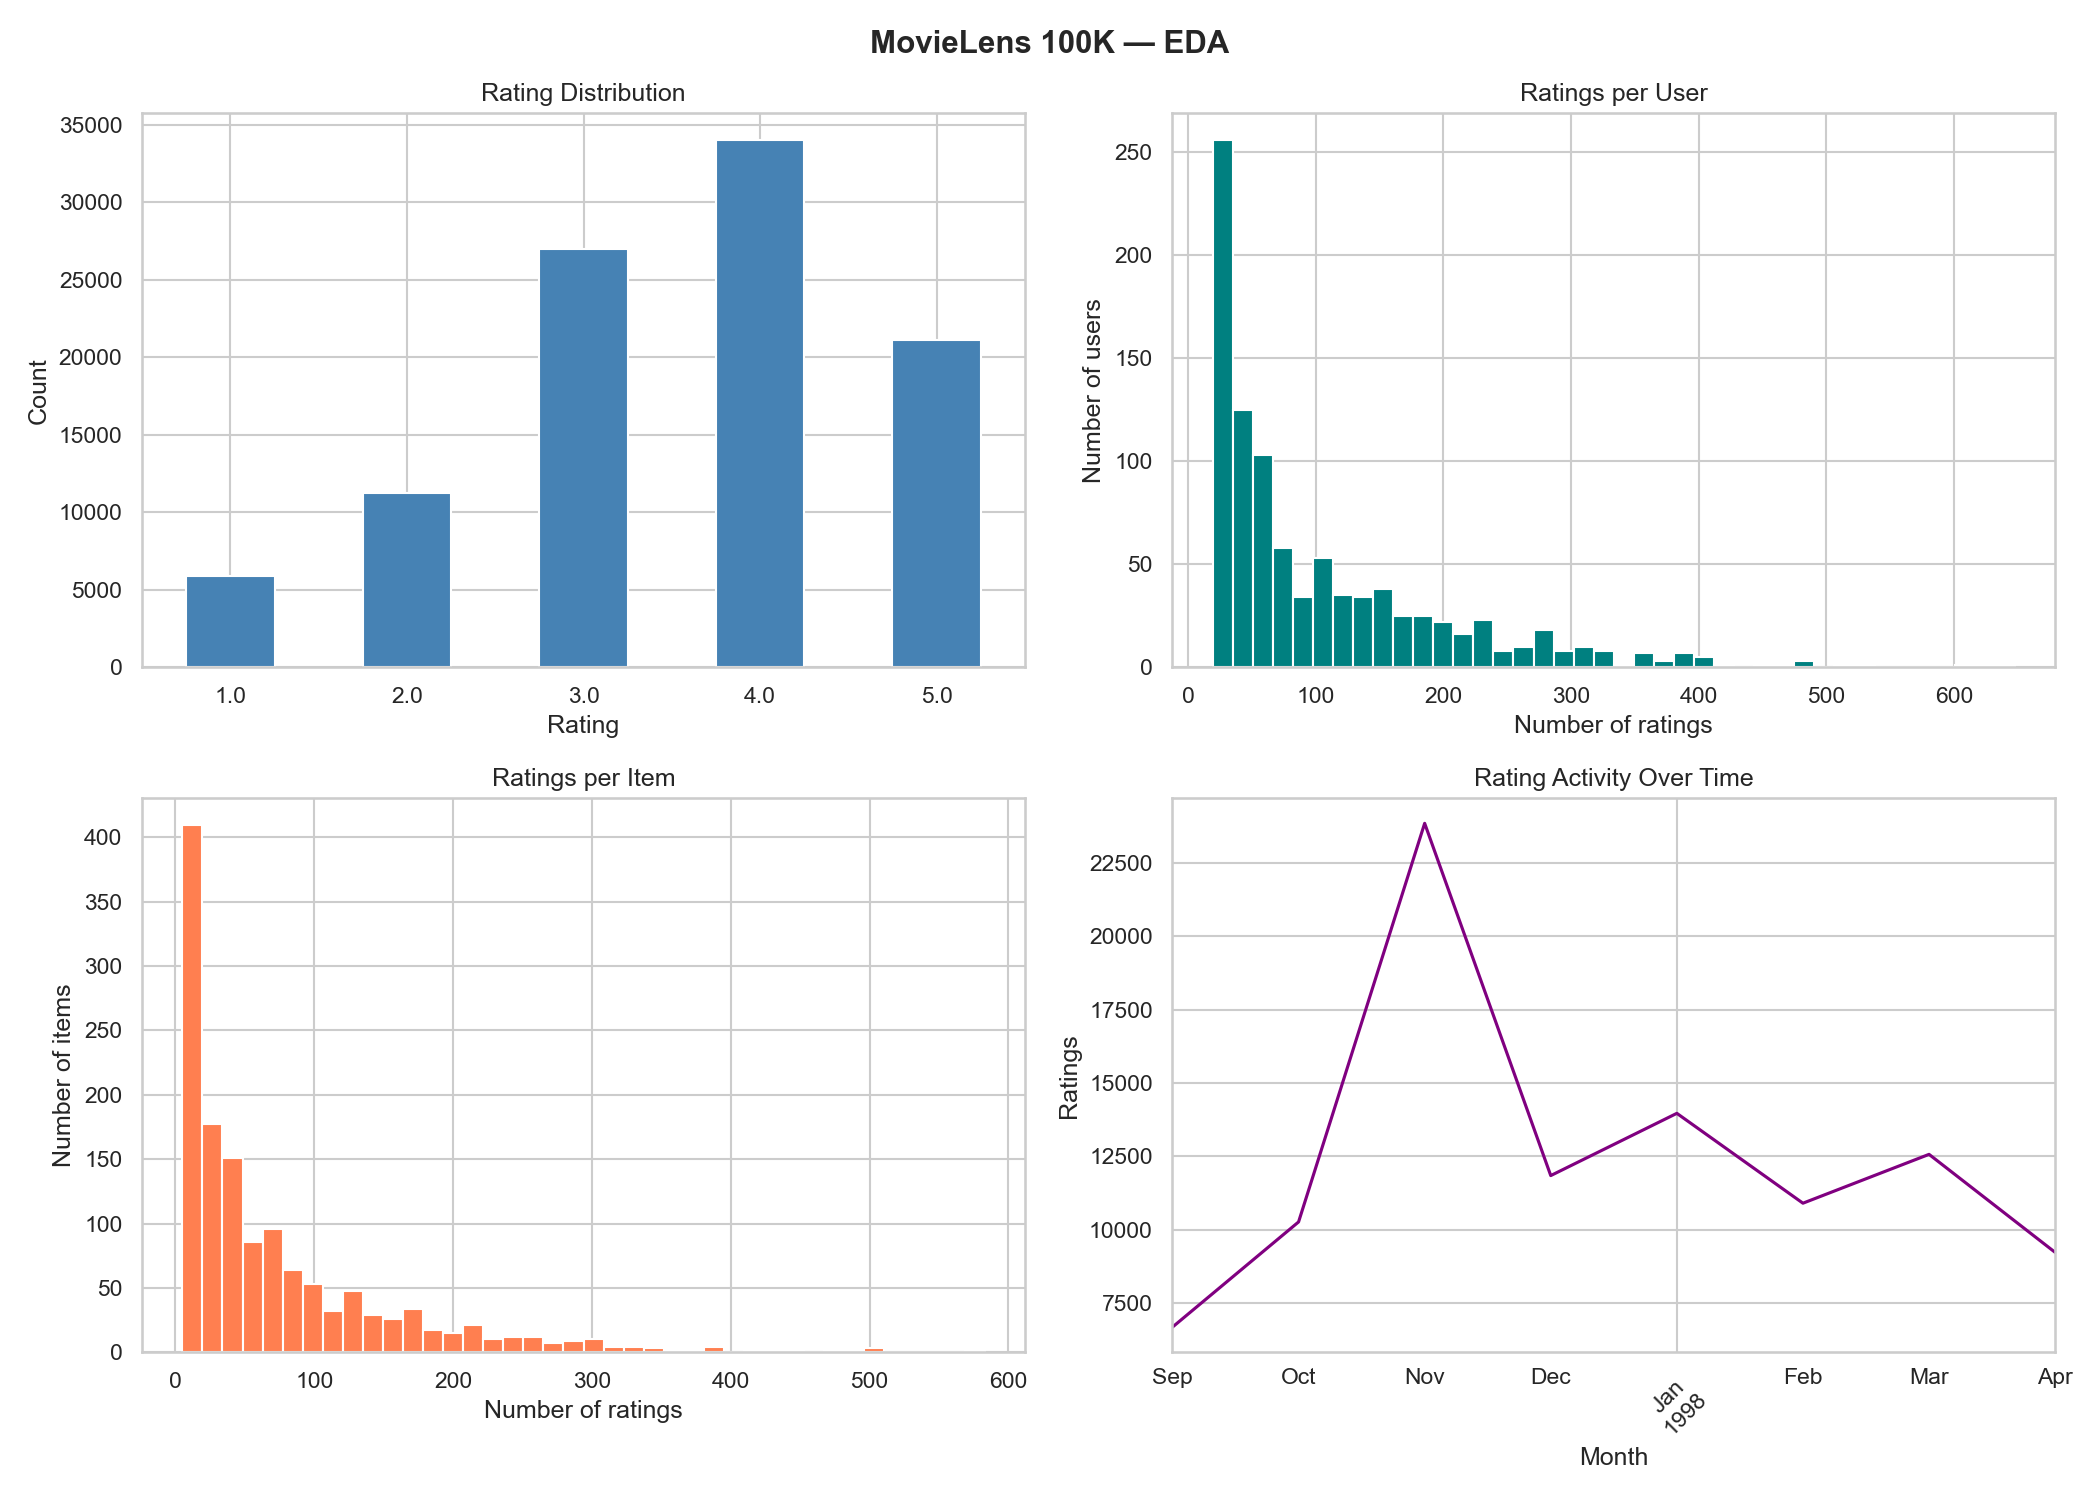

In [3]:
show_png("results/plots/eda_overview.png")


**Reading the EDA chart:**
The rating distribution skews positive (mean 3.54) — users tend to rate things
they already like, a well-known positivity bias in explicit feedback datasets.
User and item activity follow heavy-tailed distributions: a small fraction of
users and items account for a disproportionate share of all ratings, which
directly shapes the head / torso / tail breakdown seen later.


## 2. Evaluation Protocol

A shared, reproducible evaluation protocol is the backbone of a fair benchmark.
Every model is trained and measured identically.

### Splitting strategy — time-based per user

For each user, ratings are sorted by timestamp. The most recent **10 %** of
interactions become the test set; the next **10 %** become validation; the
remainder is training. Users with fewer than 5 ratings are kept entirely in
training with no holdout.

A secondary sort by `item_id` is applied as a tiebreaker: 76 % of MovieLens
100K ratings share a `(user_id, timestamp)` pair, so without it the train/test
boundary for same-second interactions is arbitrary.

> **Why time-based?** It mirrors production: a model trained on historical
> behaviour is asked to predict future preferences. Random splits leak future
> information into training and inflate metrics.

### Metrics

| Metric | What it measures |
|--------|-----------------|
| **NDCG@K** | Quality of the ranked list — rewards finding relevant items earlier |
| **Precision@K** | Fraction of the top-K recommendations that are relevant |
| **Recall@K** | Fraction of all relevant items that appear in the top-K |
| **MAP@K** | Mean Average Precision — combines precision and position |
| **RMSE / MAE** | Rating prediction accuracy (only for models that predict explicit ratings) |

K is evaluated at **5 and 10**. Primary metric throughout this report is **NDCG@10**.

### Key conventions

- **Relevance threshold:** an item is *relevant* if the user rated it **≥ 4**.
- **MAP denominator:** `min(|relevant|, K)` — standard IR convention.
- **Users with no relevant test items score 0** — they are not excluded.
  Excluding them would artificially inflate aggregate metrics.
- **All user/item IDs are normalised to plain Python `int`** before being
  passed to any model to prevent numpy int64 type mismatches.


## 3. Models

Eight algorithms spanning four paradigms, implemented from scratch.

| # | Key | Model | Paradigm | Notes |
|---|-----|-------|----------|-------|
| 1 | `popularity` | PopularityRecommender | Non-personalised | Bayesian mean-rating mode; strong baseline |
| 2 | `content_based` | ContentBasedRecommender | Content-based | 19-genre binary vectors, L2-normalised; `(rating − global_mean)` profile weights |
| 3 | `user_cf` | UserCFRecommender | Collaborative filtering | Mean-centred cosine similarity; Herlocker/Koren scoring formula |
| 4 | `item_cf` | ItemCFRecommender | Collaborative filtering | Item-item similarity on mean-centred vectors; user ratings centred at score time |
| 5 | `svd` | SVDRecommender | Matrix factorisation | Truncated SVD (scipy `svds`); supports explicit rating prediction |
| 6 | `als` | ALSRecommender | Matrix factorisation | Implicit-feedback ALS; trains on ratings ≥ 4 as implicit positives |
| 7 | `ncf` | NCFRecommender | Deep learning | NeuMF (GMF + MLP); MSE loss; supports explicit rating prediction |
| 8 | `hybrid` | HybridRecommender | Hybrid | LightFM WARP loss; 19-genre item features fused with user embeddings |

**Week 1–2 models** (Popularity, ContentBased, UserCF, ItemCF) use default
hyperparameters — no tuning was performed. All 8 models are trained on
train + val combined for the final evaluation (see Section 5).

**Week 3 models** (SVD, ALS, NCF, Hybrid) were additionally tuned with
Bayesian optimisation on the validation set (see Section 4).


## 4. Hyperparameter Tuning (Week 3 Models)

Bayesian optimisation (`scikit-optimize` GP minimiser) was used to tune each
Week 3 model. The objective is **NDCG@10 on the validation set**.
The test set is never touched during tuning.

`random_state=42` is fixed across all tuning runs so that stochastic variance
(ALS, NCF, Hybrid all have random initialisations) does not corrupt the
optimisation signal.


In [4]:
best = json.loads(Path("results/tuning/best_params.json").read_text())

spaces = {
    "svd":    "n_factors ∈ [10, 150]",
    "als":    "n_factors ∈ [10, 150]  ·  regularization ∈ [1e-4, 10]  ·  iterations ∈ [10, 50]  ·  alpha ∈ [1, 100]",
    "ncf":    "emb_size ∈ [8, 64]  ·  n_epochs ∈ [5, 20]  ·  lr ∈ [1e-4, 1e-2]",
    "hybrid": "no_components ∈ [10, 100]  ·  epochs ∈ [10, 100]",
}
calls = {"svd": 25, "als": 40, "ncf": 20, "hybrid": 30}

rows = []
for key in ["svd", "als", "ncf", "hybrid"]:
    entry = best[key]
    params_str = "  ·  ".join(f"{k}={v:.4g}" for k, v in entry["params"].items())
    rows.append({
        "Model":        key.upper(),
        "Search space": spaces[key],
        "n_calls":      calls[key],
        "Best params":  params_str,
        "Val NDCG@10":  entry["ndcg_at_10"],
    })

display(pd.DataFrame(rows).set_index("Model"))


,Search space,n_calls,Best params,Val NDCG@10
Model,,,,
SVD,"n_factors ∈ [10, 150]",25,n_factors=45,0.0746
ALS,"n_factors ∈ [10, 150] · regularization ∈ [1e...",40,n_factors=54 · regularization=8.3 · iterat...,0.1254
NCF,"emb_size ∈ [8, 64] · n_epochs ∈ [5, 20] · ...",20,emb_size=8 · n_epochs=5 · lr=0.0001,0.0497
HYBRID,"no_components ∈ [10, 100] · epochs ∈ [10, 100]",30,no_components=100 · epochs=78,0.1165


### Boundary findings — what tuning revealed

**SVD — `n_factors=45`**
Well inside the search range [10, 150]. More factors do not help; SVD overfits
beyond ~50 latent dimensions on a dataset this sparse.

**ALS — `regularization=8.3`, `alpha=1.04`**
Regularization hit the *upper* boundary in the first run (original ceiling was
1.0), so the range was extended to 10.0. The final value of 8.3 sits near the
new ceiling — ALS needs heavy regularisation to prevent popularity bias on
implicit feedback. Alpha hit the *lower* boundary of the original range
(10.0), so it was extended down to 1.0; the final value of 1.04 confirms that
low confidence scaling works better here.

**NCF — `emb_size=8`, `n_epochs=5`, `lr=0.0001`**
All three parameters landed at their **lower bounds**. The GP consistently
preferred the smallest, most regularised model configuration — a clear sign
that even minimal-capacity NeuMF overfits quickly on a dataset of this size
(~100K ratings). Larger embeddings, more epochs, and higher learning rates
all degraded validation performance.

**Hybrid — `no_components=100`, `epochs=78`**
Both parameters are at or near their **upper bounds**. LightFM with WARP loss
continues to improve with more components and longer training; the search
ceiling was the constraint, not model capacity. A wider search space would
likely yield further gains.


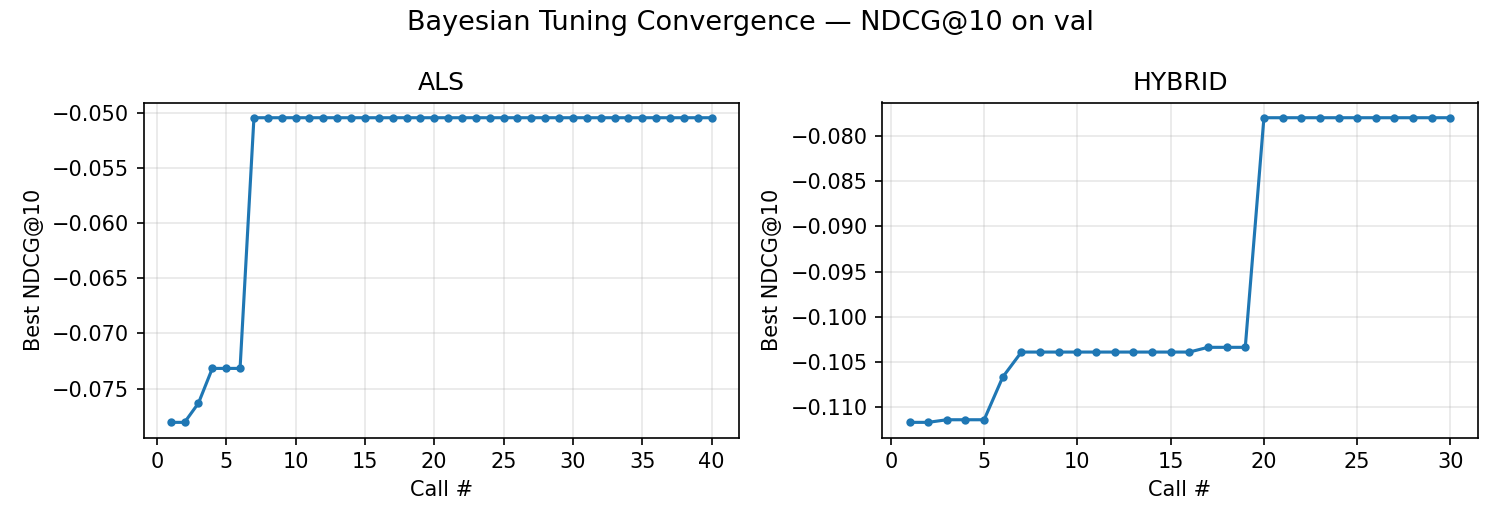

In [5]:
show_png("results/plots/tuning_convergence.png", width=1100)


Each panel shows the best observed NDCG@10 on the validation set as the
Bayesian optimiser accumulates evaluations. Flat regions indicate the search
has converged; a still-rising curve (Hybrid) indicates capacity was the
constraint, not the optimisation budget.


## 5. Final Benchmark Results

All 8 models were **retrained on train + val combined** (89,756 rows) then
evaluated once on the held-out test set (9,531 rows). Week 3 models use
tuned hyperparameters; Week 1–2 models use defaults. No model saw the test set
before this final evaluation.


In [6]:
results = pd.read_csv("results/benchmark_results.csv")
results = results.sort_values("NDCG@10", ascending=False).reset_index(drop=True)

ranking_cols = ["model", "NDCG@5", "NDCG@10", "Precision@5", "Precision@10",
                "Recall@5", "Recall@10", "MAP@5", "MAP@10"]

print("Ranking metrics")
display(
    results[ranking_cols].set_index("model")
    .style
    .format("{:.4f}")
    .highlight_max(axis=0, props="font-weight:bold; color:#4F46E5")
    .set_caption("Bold + blue = best in column")
)


Ranking metrics


,NDCG@5,NDCG@10,Precision@5,Precision@10,Recall@5,Recall@10,MAP@5,MAP@10
model,,,,,,,,
Hybrid,0.1049,0.1166,0.0834,0.0673,0.0770,0.1371,0.0692,0.0655
ALS,0.0974,0.1070,0.0761,0.0586,0.0857,0.1344,0.0613,0.0595
UserCF,0.0702,0.0752,0.0585,0.0481,0.0476,0.0808,0.0449,0.0395
ItemCF,0.0631,0.0693,0.0484,0.0413,0.0445,0.0751,0.0400,0.0369
Popularity,0.0561,0.0638,0.0426,0.0390,0.0423,0.0727,0.0358,0.0339
SVD,0.0584,0.0632,0.0448,0.0371,0.0461,0.0707,0.0364,0.0338
NCF,0.0523,0.0552,0.0452,0.0383,0.0348,0.0566,0.0312,0.0267
ContentBased,0.0061,0.0082,0.0055,0.0051,0.0057,0.0123,0.0032,0.0034


In [7]:
results = pd.read_csv("results/benchmark_results.csv")
results = results.sort_values("NDCG@10", ascending=False).reset_index(drop=True)

other_cols = ["model", "RMSE", "MAE", "train_time_s", "peak_memory_mb",
              "latency_median_ms", "latency_p95_ms"]

print("Rating prediction & efficiency metrics")
display(results[other_cols].set_index("model"))


Rating prediction & efficiency metrics


,RMSE,MAE,train_time_s,peak_memory_mb,latency_median_ms,latency_p95_ms
model,,,,,,
Hybrid,NaN,NaN,17.1130,22.4300,0.1870,0.2590
ALS,NaN,NaN,0.7150,11.7500,0.0610,0.4350
UserCF,NaN,NaN,0.1010,25.9700,0.1210,0.8410
ItemCF,NaN,NaN,0.3010,56.8700,0.1510,2.3840
Popularity,NaN,NaN,0.0680,10.2700,0.0300,0.0400
SVD,1.1191,0.8905,0.4290,52.5000,0.0670,0.0930
NCF,1.0643,0.8632,21.6080,117.2400,0.4780,1.5930
ContentBased,NaN,NaN,0.2770,13.4000,0.0680,0.1600


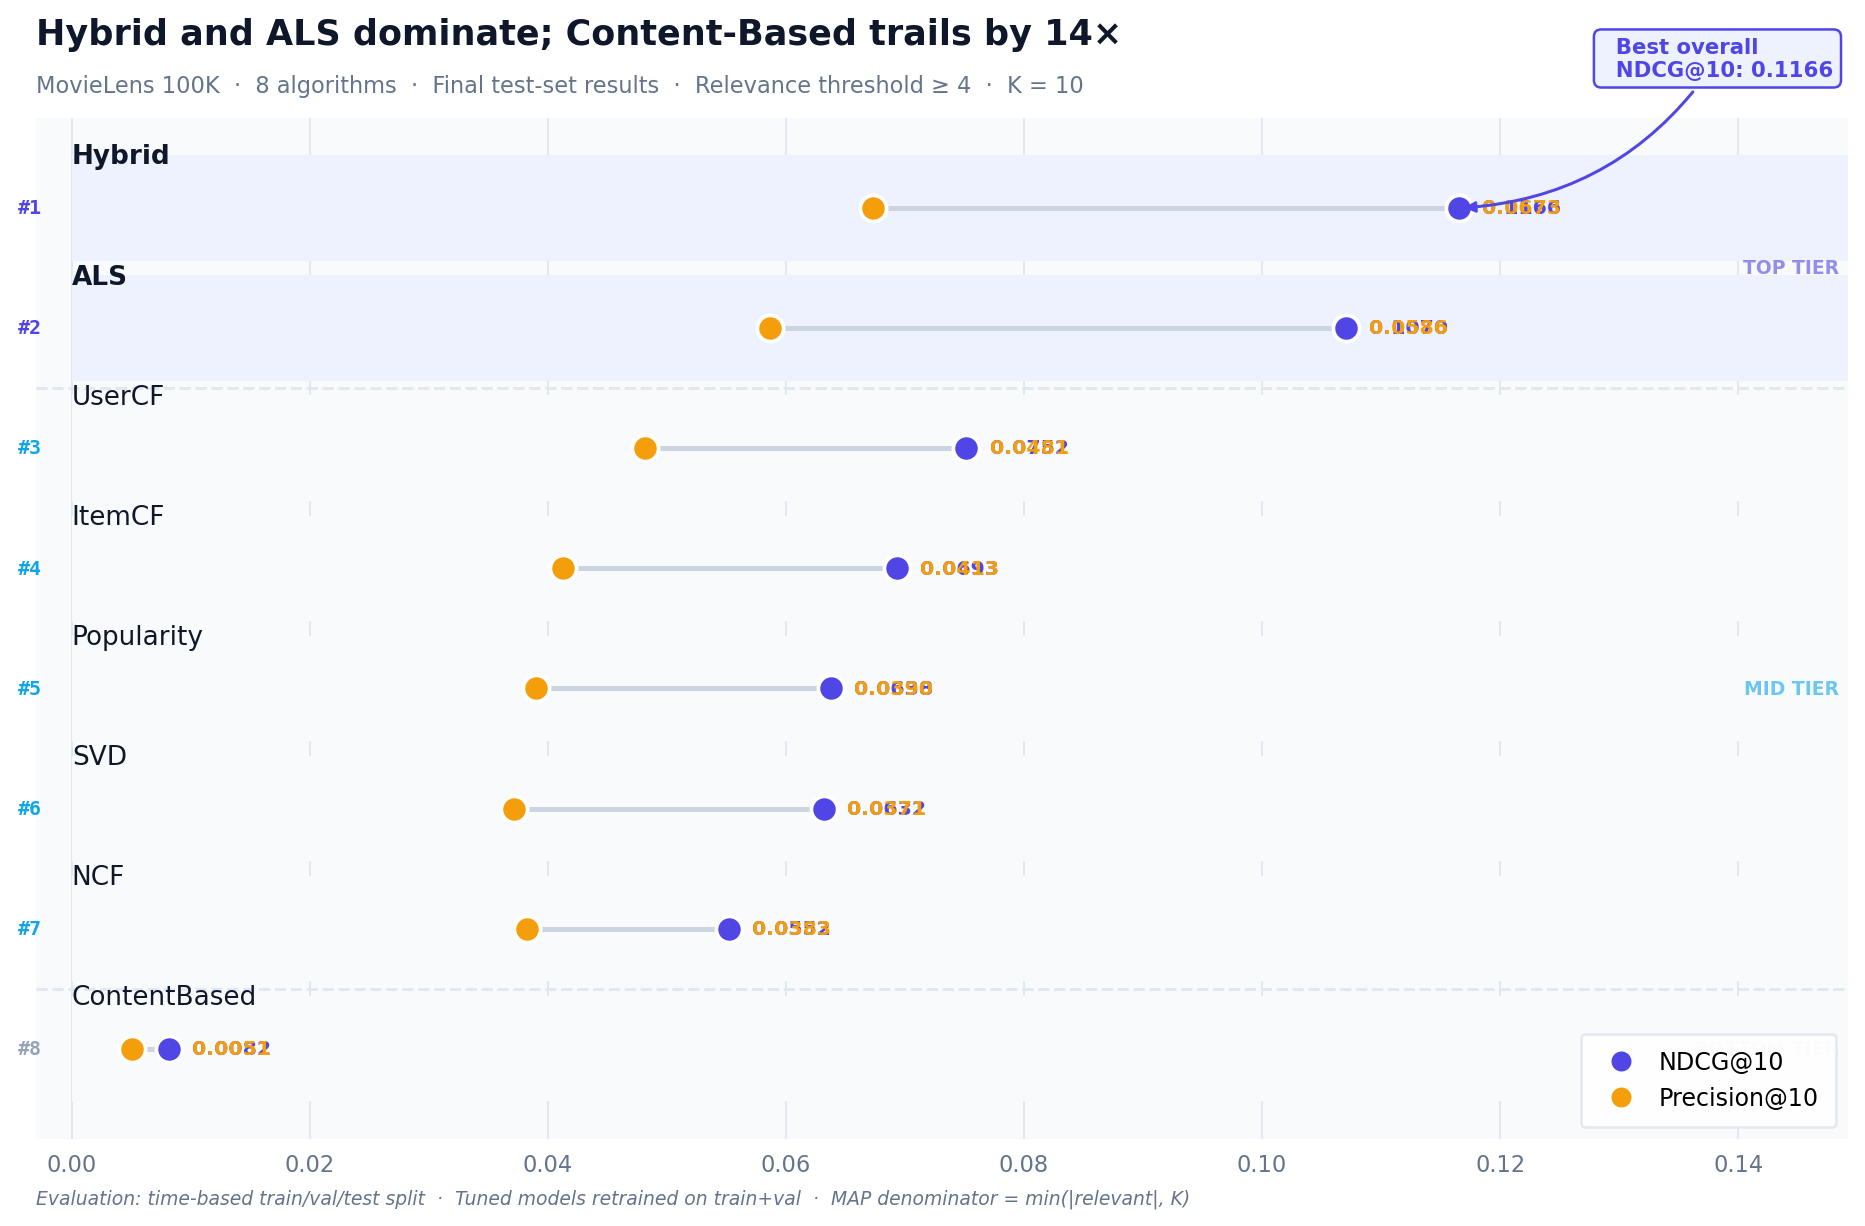

In [8]:
show_png("results/plots/benchmark_comparison.png")


### Reading the results

**Hybrid leads by a clear margin** (NDCG@10 = 0.117), followed by ALS (0.107).
Both use implicit-feedback signals effectively — Hybrid adds genre item features
on top of user-item interactions via WARP loss, which directly optimises ranking
rather than minimising rating reconstruction error.

**UserCF and ItemCF are competitive mid-tier models** despite being simple
neighbourhood methods. UserCF outperforms ItemCF on NDCG@10 (0.075 vs 0.069),
suggesting user-level similarity is more informative on this dataset than
item-level.

**SVD, NCF, and Popularity cluster tightly** (~0.055–0.064). NCF's weak
performance relative to ALS and Hybrid is notable: neural models need more data
than MovieLens 100K provides to outperform well-regularised matrix factorisation.

**ContentBased is a distant last** (0.008) — 14× lower than Hybrid. Binary
genre vectors alone cannot capture the nuanced preference structure that
collaborative signals reveal.

**On rating prediction (RMSE/MAE):** NCF edges out SVD (RMSE 1.064 vs 1.119),
but both are well above a 1-star error, reflecting the well-known difficulty of
explicit rating prediction vs. ranking.


## 6. Breakdown Analysis

Aggregate NDCG@10 hides important variation across item types and user segments.
Three targeted analyses reveal *where* models win and *where* they fail.

- **Item popularity buckets:** head (top 20 % most-rated), torso (middle 30 %),
  tail (bottom 50 %). For each bucket, NDCG@10 is computed using only the
  user's relevant items that fall in that bucket. Users with no relevant items
  in a bucket are excluded from that bucket's mean.
- **User activity tiers:** cold (≤33rd pct of train+val ratings), moderate, active.
- **Win / loss:** for each test user, which model achieves the highest NDCG@10?


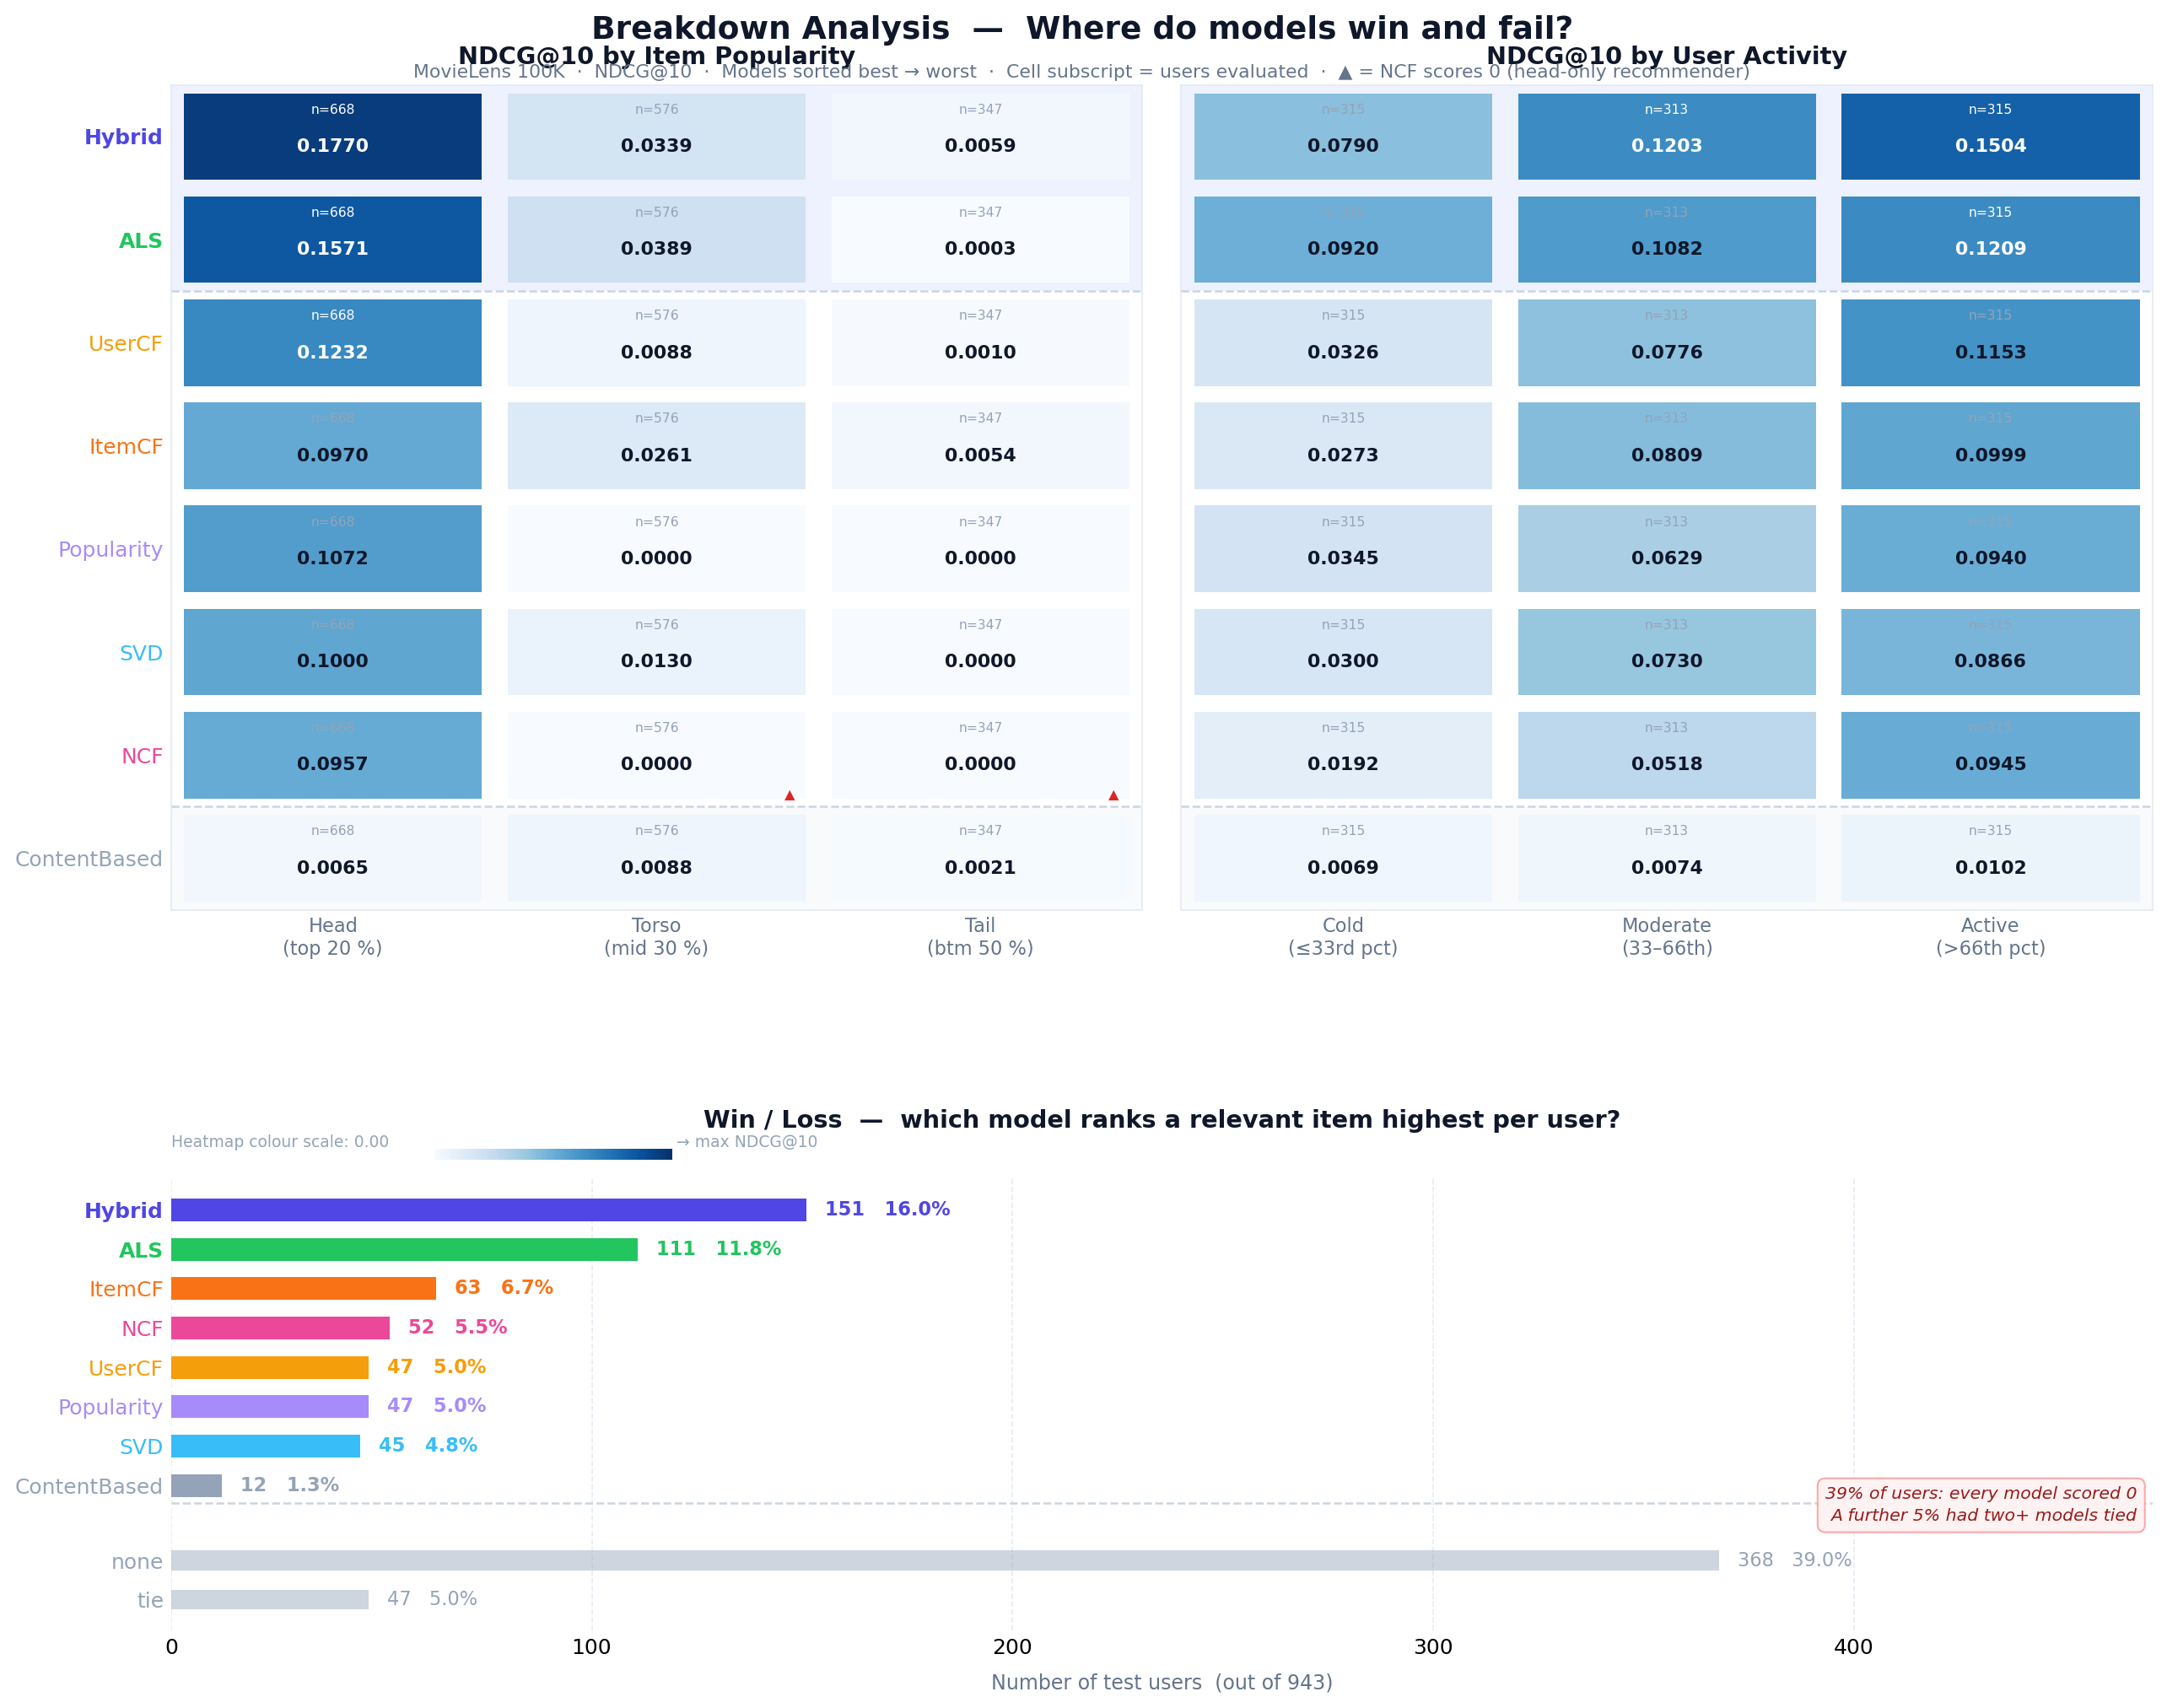

In [9]:
show_png("results/plots/breakdown_overview.png", width=1200)


### Item popularity breakdown

In [10]:
pop = pd.read_csv("results/analysis/popularity_bucket.csv")
pivot = (pop.pivot(index="model", columns="bucket", values="ndcg_at_10")
           .reindex(index=["Hybrid","ALS","UserCF","ItemCF","Popularity","SVD","NCF","ContentBased"],
                    columns=["head","torso","tail"])
           .fillna(0))
n_pivot = (pop.pivot(index="model", columns="bucket", values="n_users")
              .reindex(index=pivot.index, columns=["head","torso","tail"])
              .fillna(0).astype(int))

print(f"Users with relevant head items:  {n_pivot['head'].iloc[0]}")
print(f"Users with relevant torso items: {n_pivot['torso'].iloc[0]}")
print(f"Users with relevant tail items:  {n_pivot['tail'].iloc[0]}")
print()
display(pivot.style.format("{:.4f}").highlight_max(axis=0, props="font-weight:bold; color:#4F46E5"))


Users with relevant head items:  668
Users with relevant torso items: 576
Users with relevant tail items:  347



bucket,head,torso,tail
model,,,
Hybrid,0.1770,0.0339,0.0059
ALS,0.1571,0.0389,0.0003
UserCF,0.1232,0.0088,0.0010
ItemCF,0.0970,0.0261,0.0054
Popularity,0.1072,0.0000,0.0000
SVD,0.1000,0.0130,0.0000
NCF,0.0957,0.0000,0.0000
ContentBased,0.0065,0.0088,0.0021


**Finding:** Every model degrades sharply from head → torso → tail. Long-tail
items (bottom 50 % by rating count) are essentially unreachable — the best
tail NDCG@10 across all models is 0.0059 (Hybrid).

**NCF scores exactly 0 on torso and tail** — it exclusively recommends head
items. With `emb_size=8`, its embedding space collapses toward popular items
and cannot distinguish preferences for less-common content.

**ContentBased shows the most even degradation** — it is equally poor across all
three buckets — because genre features are independent of popularity, but too
coarse to discriminate user preferences.


### User activity breakdown

In [11]:
from src.analysis.breakdown import bucket_users_by_activity, USER_TIER_QUANTILES
import pandas as pd

act = pd.read_csv("results/analysis/user_activity.csv")
pivot_a = (act.pivot(index="model", columns="tier", values="ndcg_at_10")
              .reindex(index=["Hybrid","ALS","UserCF","ItemCF","Popularity","SVD","NCF","ContentBased"],
                       columns=["cold","moderate","active"])
              .fillna(0))
n_pivot_a = (act.pivot(index="model", columns="tier", values="n_users")
                .reindex(index=pivot_a.index, columns=["cold","moderate","active"])
                .fillna(0).astype(int))

# Compute boundaries from actual data (not hardcoded)
train_val = pd.concat([data["train"], data["val"]], ignore_index=True)
counts = train_val.groupby("user_id").size()
q33 = int(counts.quantile(USER_TIER_QUANTILES[0]))
q66 = int(counts.quantile(USER_TIER_QUANTILES[1]))

print(f"Cold users     (≤{q33} train+val ratings): {n_pivot_a['cold'].iloc[0]}")
print(f"Moderate users ({q33}–{q66} ratings):    {n_pivot_a['moderate'].iloc[0]}")
print(f"Active users   (>{q66} ratings):          {n_pivot_a['active'].iloc[0]}")
print()
display(pivot_a.style.format("{:.4f}").highlight_max(axis=0, props="font-weight:bold; color:#4F46E5"))


Cold users     (≤37 train+val ratings): 315
Moderate users (37–101 ratings):    313
Active users   (>101 ratings):          315



tier,cold,moderate,active
model,,,
Hybrid,0.0790,0.1203,0.1504
ALS,0.0920,0.1082,0.1209
UserCF,0.0326,0.0776,0.1153
ItemCF,0.0273,0.0809,0.0999
Popularity,0.0345,0.0629,0.0940
SVD,0.0300,0.0730,0.0866
NCF,0.0192,0.0518,0.0945
ContentBased,0.0069,0.0074,0.0102


**Finding:** All models degrade for cold users, but at very different rates.

**ALS degrades more gracefully than UserCF** on cold users (0.092 vs 0.033).
Matrix factorisation regularises item factors globally, so even sparse users get
reasonable recommendations via item embeddings. UserCF needs enough neighbours
with overlapping history — cold users have too few ratings to find good
neighbours.

**Hybrid is best for cold users** (0.079) and best overall for active users
(0.150), making it the most robust model across the activity spectrum.

The cold-user gap is the largest driver of aggregate NDCG@10 differences:
Hybrid's lead over UserCF is widest precisely where UserCF is weakest.


### Win / loss

In [12]:
win = pd.read_csv("results/analysis/win_loss_summary.csv")
win = win.sort_values("wins", ascending=False).reset_index(drop=True)
win["win_rate"] = win["win_rate"].map("{:.1%}".format)

model_wins = win[~win["model"].isin(["none", "tie"])]
meta_wins  = win[win["model"].isin(["none", "tie"])]

print("Model wins (strictly highest NDCG@10 per user):")
display(model_wins.set_index("model"))
print()
print("Non-winner outcomes:")
display(meta_wins.set_index("model"))


Model wins (strictly highest NDCG@10 per user):


,wins,win_rate
model,,
Hybrid,151,16.0%
ALS,111,11.8%
ItemCF,63,6.7%
NCF,52,5.5%
Popularity,47,5.0%
UserCF,47,5.0%
SVD,45,4.8%
ContentBased,12,1.3%



Non-winner outcomes:


,wins,win_rate
model,,
none,368,39.0%
tie,47,5.0%


**Finding:** 39% of test users — 368 out of 943 — had **no model
find a relevant item** in the top 10. This is the dominant failure mode, not any
model-specific weakness. It reflects the fundamental challenge: with 7.8%
matrix density and a relevance threshold of 4 stars, most users have few
relevant items in the test set, and recommendation at K=10 is a narrow window.

**Hybrid wins for 16% of users (151), ALS for 12% (111).**
Together they account for more wins than all other models combined.

**47 users had two or more models achieve the same non-zero NDCG@10** —
these are genuine ties, typically cases where multiple models recommended the
same relevant item at the same rank position.


## 7. Key Findings

### What worked

1. **Hybrid (LightFM WARP + genre features) is the clear winner** at NDCG@10
   = 0.117. The combination of implicit-feedback optimisation (WARP loss
   directly optimises ranking) and item-side genre features outperforms all
   purely collaborative approaches.

2. **ALS is the best pure collaborative filtering model** (0.107), outperforming
   UserCF (0.075) and ItemCF (0.069) by a wide margin. Implicit-feedback ALS
   handles the 7.8% sparsity better than neighbourhood methods.

3. **Bayesian tuning added meaningful value for ALS and Hybrid.** The boundary
   findings were not obvious a priori: ALS needed unusually high regularisation
   (8.3) to prevent popularity bias; Hybrid wanted more components than the
   original search ceiling allowed.

### What didn't work

4. **NCF underperforms despite being the most complex model** (NDCG@10 = 0.055,
   last among personalised models). The tuner consistently preferred the smallest,
   most regularised configuration — `emb_size=8`, `n_epochs=5`, `lr=0.0001` — all
   at lower bounds. This indicates NeuMF overfits at any reasonable capacity on a
   dataset of ~100K ratings; larger models degraded validation performance.

5. **ContentBased is 14× worse than Hybrid** (0.008 vs 0.117). 19-genre binary
   vectors are too coarse a content representation: most users have watched films
   across the same few genres, so genre profiles cannot discriminate between items.

### Systemic failures shared by all models

6. **Long-tail items are essentially unreachable.** Every model's NDCG@10 drops
   to near zero for tail items (bottom 50 % by popularity). All models learn to
   recommend popular items because the training signal is dominated by popular
   items.

7. **39% of test users are unserved** — no model found a relevant item in
   the top 10. This ceiling matters more than the ranking differences between
   models. Improving it requires a better relevance definition, a larger K, or
   richer data.

8. **Cold users remain hard.** The gap between cold (≤37 train+val ratings)
   and active (>101 ratings) is 2–4× for all models. Neighbourhood methods are
   most sensitive; matrix factorisation degrades more gracefully.

---

*All results are on the held-out test set. Models were retrained on train + val
combined using tuned hyperparameters before final evaluation. The test set was
never used during model selection or tuning.*
